# SECTION 0 — COLAB ENVIRONMENT SETUP

This section bootstraps the Colab runtime from scratch with short, independent cells: mount Drive, check GPU, install packages, run imports, set seeds, and define all paths/config in one place.

In [3]:
# 0.1 Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
## Replace 'path/to/your/dataset.zip' with the actual path you copied
!unzip -q "/content/drive/MyDrive/htx_deglare/SD1_Trimmed.zip" -d "/content/drive/MyDrive/htx_deglare/SD1_dataset"

In [5]:
#from google.colab import drive
#drive.mount('/content/drive')
import sys
import os

# 1. Mount Google Drive
# drive.mount('/content/drive')

# 2. Navigate to your folder
# Replace 'notebook' with the actual name of your folder in Drive
project_path = '/content/drive/MyDrive/htx_deglare/notebooks/'
os.chdir(project_path)

# 3. Add the folder to the system path so you can import your .py files
sys.path.append(project_path)

# 4. Verify files are there
print("Files in directory:", os.listdir())

Files in directory: ['model.py', 'loss.py', 'dataset.py', 'deglare.ipynb']


In [1]:
# 0.2 GPU check (direct Colab style)
!nvidia-smi

import torch
if not torch.cuda.is_available():
    print('[WARNING] CUDA not available. Please set Runtime -> Change runtime type -> T4 GPU.')
else:
    print('CUDA available:', torch.cuda.is_available())
    print('GPU name:', torch.cuda.get_device_name(0))

Tue Apr 21 15:02:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
# 0.3 Install required packages (direct !pip style)
!pip install -q opencv-python scikit-image scikit-learn scipy tqdm matplotlib numpy

In [8]:
# 0.4 Torch/torchvision minimal check (install only if missing)
import importlib.util

missing_torch = (
    importlib.util.find_spec('torch') is None
    or importlib.util.find_spec('torchvision') is None
)
print('Is torch/torchvision missing?', missing_torch)
if missing_torch:
    !pip install -q torch torchvision

Is torch/torchvision missing? False


In [9]:
# 0.5 All imports (grouped)

# standard library
import json
import logging
import os
import random
import tempfile
from datetime import datetime
from pathlib import Path

# numpy/cv2/scipy
import cv2
import numpy as np
import scipy

# matplotlib
import matplotlib
import matplotlib.pyplot as plt

# skimage metrics
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn

# sklearn
import sklearn

# tqdm
from tqdm.auto import tqdm

# torch/nn/optim/DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# albumentations
# import albumentations as A

# project modules (direct imports)
from dataset import SD1Dataset, get_dataloaders
from model import DeglarUNet, count_parameters, estimate_gflops

In [10]:
# 0.6 Reproducibility + versions
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('python:', __import__('sys').version.split()[0])
print('torch:', torch.__version__)
print('numpy:', np.__version__)
print('opencv:', cv2.__version__)
print('scipy:', scipy.__version__)
print('matplotlib:', matplotlib.__version__)
print('scikit-image:', __import__('skimage').__version__)
print('scikit-learn:', sklearn.__version__)
print('tqdm:', __import__('tqdm').__version__)
# print('albumentations:', A.__version__)

python: 3.12.13
torch: 2.10.0+cu128
numpy: 2.0.2
opencv: 4.13.0
scipy: 1.16.3
matplotlib: 3.10.0
scikit-image: 0.25.2
scikit-learn: 1.6.1
tqdm: 4.67.3


In [67]:
# 0.7 Paths and hyperparameter config + sanity checks

if os.path.isdir('/content/drive/MyDrive/htx_deglare/notebooks/'):
    os.chdir('/content/drive/MyDrive/htx_deglare/notebooks/')
print('Current working directory:', os.getcwd())
!ls -l

TRAIN_DIR = '/content/drive/MyDrive/htx_deglare/SD1_dataset/SD1_Trimmed/train'
VAL_DIR = '/content/drive/MyDrive/htx_deglare/SD1_dataset/SD1_Trimmed/val'
BEST_CHECKPOINT_PATH = '/content/drive/MyDrive/deglare_checkpoints/best_model.pth'
EXPERIMENTS_ROOT = '/content/drive/MyDrive/deglare_experiments/'

BATCH_SIZE = 4
VAL_BATCH_SIZE = 4
NUM_EPOCHS = 20
LEARNING_RATE = 3e-4
NUM_WORKERS = 2
WEIGHT_DECAY = 0.0
SCHEDULER_FACTOR = 0.5
SCHEDULER_PATIENCE = 2
MIN_LR = 1e-6

os.makedirs(os.path.dirname(BEST_CHECKPOINT_PATH), exist_ok=True)
os.makedirs(EXPERIMENTS_ROOT, exist_ok=True)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


def count_pngs(folder: str) -> int:
    return len(list(Path(folder).rglob('*.png'))) if os.path.isdir(folder) else 0

print('Train PNG count:', count_pngs(TRAIN_DIR))
print('Val PNG count:', count_pngs(VAL_DIR))
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
print('Best checkpoint exists:', os.path.exists(BEST_CHECKPOINT_PATH))
print('Experiments root:', EXPERIMENTS_ROOT)

Current working directory: /content/drive/MyDrive/htx_deglare/notebooks
total 506
-rw------- 1 root root   9202 Apr 21 15:32 dataset.py
-rw------- 1 root root 485998 Apr 21 16:42 deglare.ipynb
-rw------- 1 root root   3223 Apr 21 12:05 loss.py
-rw------- 1 root root  13951 Apr 21 08:49 model.py
drwx------ 2 root root   4096 Apr 21 15:05 __pycache__
Train PNG count: 3000
Val PNG count: 300
Device: cuda:0
GPU: Tesla T4
VRAM: 14.56 GB
Best checkpoint exists: True
Experiments root: /content/drive/MyDrive/deglare_experiments/


# SECTION 1 — ASSUMPTIONS AND DESIGN DECISIONS

- **SD1 panel layout**: each image stores `GT | Glare | Mask` horizontally; we train only on GT and glare, so mask is discarded.
- **Why grayscale**: matches assignment constraint and reduces computation/VRAM.
- **Why paired augmentation**: geometric transforms must be synchronized for input/target alignment; paired pipelines avoid supervision mismatch.
- **Why U-Net + skips**: skip connections preserve spatial detail while deeper blocks capture global context.
- **Why L1 over L2**: L1 usually gives sharper reconstructions and is the assignment’s main metric.
- **PSNR/SSIM**: supplementary perceptual quality indicators.
- **Adam + ReduceLROnPlateau**: stable optimization + adaptive LR decay when validation stagnates.
- **Dual checkpoints**: best + last protects progress and helps Colab recovery.

# SECTION 2 — DATA LOADING AND PREPROCESSING

Create train/val dataloaders, run one sanity batch check, and visualize glare-vs-GT pairs.

In [68]:
# 2.1 Build dataloaders
train_loader, val_loader = get_dataloaders(
    train_dir=TRAIN_DIR,
    val_dir=VAL_DIR,
    batch_size=BATCH_SIZE,
    val_batch_size=VAL_BATCH_SIZE,
    num_workers=NUM_WORKERS,
    enable_augment=True,
)

print('Train samples:', len(train_loader.dataset))
print('Val samples:', len(val_loader.dataset))
print('Train batches:', len(train_loader))
print('Val batches:', len(val_loader))

Train samples: 3000
Val samples: 300
Train batches: 750
Val batches: 75


In [69]:
# 2.2 Batch sanity check
glare_batch, gt_batch = next(iter(train_loader))
print('Glare batch shape:', tuple(glare_batch.shape))
print('GT batch shape:', tuple(gt_batch.shape))
print(f"Glare range: [{glare_batch.min().item():.4f}, {glare_batch.max().item():.4f}]")
print(f"GT range:    [{gt_batch.min().item():.4f}, {gt_batch.max().item():.4f}]")

Glare batch shape: (4, 1, 512, 512)
GT batch shape: (4, 1, 512, 512)
Glare range: [0.2275, 1.0000]
GT range:    [0.1765, 0.9255]


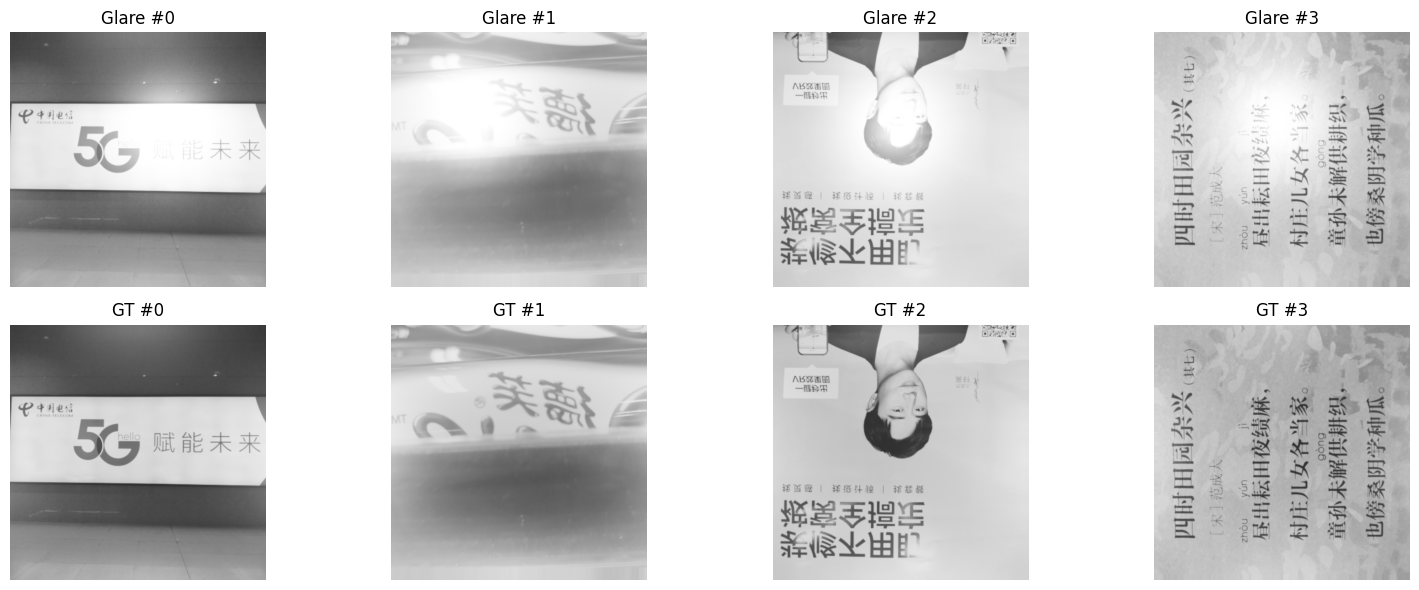

In [70]:
# 2.3 Visualize one batch (4 samples)
n_show = min(4, glare_batch.shape[0])
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 6))
if n_show == 1:
    axes = np.array(axes).reshape(2, 1)

for i in range(n_show):
    axes[0, i].imshow(glare_batch[i, 0].cpu().numpy(), cmap='gray', vmin=0.0, vmax=1.0)
    axes[0, i].set_title(f'Glare #{i}')
    axes[0, i].axis('off')

    axes[1, i].imshow(gt_batch[i, 0].cpu().numpy(), cmap='gray', vmin=0.0, vmax=1.0)
    axes[1, i].set_title(f'GT #{i}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# SECTION 3 — MODEL DEFINITION AND INSPECTION

Initialize several `DeglarUNet` variants, report params/GFLOPs/checkpoint size, assert size `< 6 MB`, and test batch-size 4/8 forward passes.

In [71]:
# 3.1 Device + state_dict size helper
print('Device:', DEVICE)


def state_dict_size_mb(model: nn.Module) -> float:
    temp_path = os.path.join(tempfile.gettempdir(), 'deglar_tmp_state.pth')
    torch.save(model.state_dict(), temp_path)
    size_mb = os.path.getsize(temp_path) / (1024 * 1024)
    if os.path.exists(temp_path):
        os.remove(temp_path)
    return float(size_mb)

Device: cuda:0


In [72]:
# 3.2 Model inspection across configs
model_test_configs = [
    {'name': 'cfg_a_l4_r1', 'kwargs': {'level': 4, 'channel_ratio': 1, 'decoder_mode': 'deconv', 'use_depthwise': False}},# 109.G, 30M
    {'name': 'cfg_a_l4_r1_dw', 'kwargs': {'level': 4, 'channel_ratio': 1, 'decoder_mode': 'deconv', 'use_depthwise': True}}, # 28.6G, 6M
    {'name': 'cfg_a_l3_r0.5_dw', 'kwargs': {'level': 4, 'channel_ratio': 0.5, 'decoder_mode': 'deconv', 'use_depthwise': True}}, # 7.5G, 1.5M
    {'name': 'cfg_a_l3_r0.5_devone', 'kwargs': {'level': 3, 'channel_ratio': 0.5, 'decoder_mode': 'deconv_oneconv', 'use_depthwise': False}},#21G,2M
    {'name': 'cfg_a_l3_r0.25_dw_devone', 'kwargs': {'level': 3, 'channel_ratio': 0.5, 'decoder_mode': 'deconv_oneconv', 'use_depthwise': True}}, #22G, 1.5M
    {'name': 'cfg_a_l3_r0.25_dw_devone', 'kwargs': {'level': 3, 'channel_ratio': 0.5, 'decoder_mode': 'deconv_oneconv', 'use_depthwise': True}}, #5.7G, 0.455M
    {'name': 'cfg_a_l3_r0.25_devone', 'kwargs': {'level': 3, 'channel_ratio': 0.25, 'decoder_mode': 'deconv_oneconv', 'use_depthwise': False}},
    {'name': 'cfg_b_l3_r0.125_dw_bilione', 'kwargs': {'level': 3, 'channel_ratio': 0.125, 'decoder_mode': 'bilinear_oneconv', 'use_depthwise': True}},
    {'name': 'cfg_c_l2_r0.5_dw_bilione', 'kwargs': {'level': 2, 'channel_ratio': 0.5, 'decoder_mode': 'bilinear_oneconv', 'use_depthwise': True}},
]

for cfg in model_test_configs:
    m = DeglarUNet(**cfg['kwargs']).cpu()
    total_params = sum(p.numel() for p in m.parameters())
    trainable_params = count_parameters(m)
    gflops = estimate_gflops(m, input_shape=(1, 1, 512, 512))
    size_mb = state_dict_size_mb(m)

    print(f"\n[{cfg['name']}]")
    print('kwargs:', cfg['kwargs'])
    print('total params:', f"{total_params:,}")
    print('trainable params:', f"{trainable_params:,}")
    print('estimated GFLOPs:', f"{gflops:.3f}")
    print('state_dict size (MB):', f"{size_mb:.3f}")

    # assert size_mb < 6.0, f"{cfg['name']} exceeds 6 MB: {size_mb:.3f}"
    if size_mb >= 6.0:
      print(f"!!! {cfg['name']} exceeds 6 MB: {size_mb:.3f}")

print('\nAll tested configs satisfy size < 6 MB.')


[cfg_a_l4_r1]
kwargs: {'level': 4, 'channel_ratio': 1, 'decoder_mode': 'deconv', 'use_depthwise': False}
total params: 7,761,985
trainable params: 7,761,985
estimated GFLOPs: 109.153
state_dict size (MB): 29.673
!!! cfg_a_l4_r1 exceeds 6 MB: 29.673

[cfg_a_l4_r1_dw]
kwargs: {'level': 4, 'channel_ratio': 1, 'decoder_mode': 'deconv', 'use_depthwise': True}
total params: 1,518,700
trainable params: 1,518,700
estimated GFLOPs: 28.631
state_dict size (MB): 5.915

[cfg_a_l3_r0.5_dw]
kwargs: {'level': 4, 'channel_ratio': 0.5, 'decoder_mode': 'deconv', 'use_depthwise': True}
total params: 389,180
trainable params: 389,180
estimated GFLOPs: 7.473
state_dict size (MB): 1.584

[cfg_a_l3_r0.5_devone]
kwargs: {'level': 3, 'channel_ratio': 0.5, 'decoder_mode': 'deconv_oneconv', 'use_depthwise': False}
total params: 433,729
trainable params: 433,729
estimated GFLOPs: 17.197
state_dict size (MB): 1.685

[cfg_a_l3_r0.25_dw_devone]
kwargs: {'level': 3, 'channel_ratio': 0.5, 'decoder_mode': 'deconv_onec

In [73]:
# 3.3 Dummy forward checks with batch size 4 and 8
for cfg in model_test_configs:
    m = DeglarUNet(**cfg['kwargs']).to(DEVICE).eval()
    print(f"\nForward check: {cfg['name']}")
    device = next(m.parameters()).device
    print(f"Model is running on: {device}")


    for bs in (4, 8, 16):
        try:
            x = torch.randn(bs, 1, 512, 512, device=DEVICE)
            with torch.no_grad():
                y = m(x)
            assert tuple(y.shape) == tuple(x.shape), f"shape mismatch {x.shape} vs {y.shape}"
            print(f"batch={bs}: output shape={tuple(y.shape)}, range=[{y.min().item():.4f}, {y.max().item():.4f}]")
            print(f"y on cuda: {y.is_cuda}")
        except RuntimeError as e:
            if 'out of memory' in str(e).lower():
                print(f"[WARNING] OOM at batch={bs} for {cfg['name']}")
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
            else:
                raise


Forward check: cfg_a_l4_r1
Model is running on: cuda:0
batch=4: output shape=(4, 1, 512, 512), range=[0.4900, 0.5073]
y on cuda: True
batch=8: output shape=(8, 1, 512, 512), range=[0.4904, 0.5090]
y on cuda: True
batch=16: output shape=(16, 1, 512, 512), range=[0.4895, 0.5083]
y on cuda: True

Forward check: cfg_a_l4_r1_dw
Model is running on: cuda:0
batch=4: output shape=(4, 1, 512, 512), range=[0.4571, 0.4574]
y on cuda: True
batch=8: output shape=(8, 1, 512, 512), range=[0.4571, 0.4574]
y on cuda: True
batch=16: output shape=(16, 1, 512, 512), range=[0.4570, 0.4574]
y on cuda: True

Forward check: cfg_a_l3_r0.5_dw
Model is running on: cuda:0
batch=4: output shape=(4, 1, 512, 512), range=[0.4585, 0.4586]
y on cuda: True
batch=8: output shape=(8, 1, 512, 512), range=[0.4584, 0.4586]
y on cuda: True
batch=16: output shape=(16, 1, 512, 512), range=[0.4584, 0.4586]
y on cuda: True

Forward check: cfg_a_l3_r0.5_devone
Model is running on: cuda:0
batch=4: output shape=(4, 1, 512, 512), ra

# SECTION 4 — METRIC HELPERS

PSNR and SSIM are used as supplementary quality metrics:
- PSNR: pixel-level fidelity (higher is better)
- SSIM: structural similarity (closer to 1 is better)

The helper computes batch-averaged PSNR/SSIM from `[B,1,H,W]` tensors in `[0,1]`.

In [74]:
def compute_metrics(pred_tensor: torch.Tensor, gt_tensor: torch.Tensor) -> tuple[float, float]:
    pred_np = pred_tensor.detach().clamp(0.0, 1.0).cpu().numpy()
    gt_np = gt_tensor.detach().clamp(0.0, 1.0).cpu().numpy()

    psnr_vals, ssim_vals = [], []
    for i in range(pred_np.shape[0]):
        pred_img = pred_np[i, 0]
        gt_img = gt_np[i, 0]
        psnr_vals.append(psnr_fn(gt_img, pred_img, data_range=1.0))
        ssim_vals.append(ssim_fn(gt_img, pred_img, data_range=1.0))

    return float(np.mean(psnr_vals)), float(np.mean(ssim_vals))

# SECTION 5 — TRAINING LOOP

This section uses L1 objective, Adam, and ReduceLROnPlateau with tqdm progress bars.
It supports both fresh training and resume training (`last` / `best` / specific checkpoint path).

In [75]:
# 5.1 Training config + experiment/resume flags
TRAIN_MODEL_CONFIG = {
    'level': 4,
    'channel_ratio': 1,
    'decoder_mode': 'deconv',
    'use_depthwise': False,
}

CHECKPOINT_EVERY = 1

# Mini-run debug block
RUN_MINI_RUN = True
MINI_EPOCHS = 1
MINI_TRAIN_STEPS = int(3000/4)
MINI_VAL_STEPS = int(300/2)

# Resume options
RESUME_TRAINING = False
RESUME_MODE = 'last'   # 'last' | 'best' | 'path'
RESUME_EXPERIMENT_DIR = ''
RESUME_CHECKPOINT_PATH = ''

criterion = nn.L1Loss()

In [76]:
# 5.2 Build model, optimizer, scheduler
model = DeglarUNet(**TRAIN_MODEL_CONFIG).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=SCHEDULER_FACTOR,
    patience=SCHEDULER_PATIENCE,
    min_lr=MIN_LR,
)

In [77]:
# 5.3 Logging and artifact paths (append mode if resume)
EXP_NO = 1
if RESUME_TRAINING:
    if not RESUME_EXPERIMENT_DIR:
        raise ValueError('RESUME_EXPERIMENT_DIR must be set when RESUME_TRAINING=True')
    EXP_DIR = RESUME_EXPERIMENT_DIR
else:
    EXP_DIR = os.path.join(EXPERIMENTS_ROOT, f"Exp{EXP_NO}_{datetime.now().strftime('%Y%m%d_%H%M%S')}")

os.makedirs(EXP_DIR, exist_ok=True)

LOG_PATH = os.path.join(EXP_DIR, 'training.log')
BEST_MODEL_EXP_PATH = os.path.join(EXP_DIR, 'best_model.pth')
LAST_MODEL_EXP_PATH = os.path.join(EXP_DIR, 'last_model.pth')
EPOCH_LOSSES_JSON = os.path.join(EXP_DIR, 'epoch_losses.json')
METRICS_JSON = os.path.join(EXP_DIR, 'metrics_history.json')

logger = logging.getLogger('deglare_train')
logger.setLevel(logging.INFO)
logger.handlers.clear()
fh = logging.FileHandler(LOG_PATH, mode='a' if RESUME_TRAINING else 'w')
fh.setFormatter(logging.Formatter('%(asctime)s | %(message)s'))
logger.addHandler(fh)
logger.propagate = False

print('Experiment dir:', EXP_DIR)
print('Log path:', LOG_PATH)

Experiment dir: /content/drive/MyDrive/deglare_experiments/Exp1_20260421_164308
Log path: /content/drive/MyDrive/deglare_experiments/Exp1_20260421_164308/training.log


In [78]:
# 5.4 Helpers: train/val epoch + checkpoint save/load + resume path resolve

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    epoch: int,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    logger: logging.Logger,
    global_step: int,
    max_steps: int | None = None,
):
    model.train()
    loss_sum = 0.0
    psnr_vals, ssim_vals = [], []
    steps = 0

    pbar = tqdm(loader, desc=f'Train Epoch {epoch}', leave=False)
    for step_idx, (glare, gt) in enumerate(pbar, start=1):
        if max_steps is not None and step_idx > max_steps:
            break

        glare = glare.to(DEVICE, non_blocking=True)
        gt = gt.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        pred = model(glare)
        loss = criterion(pred, gt)
        loss.backward()
        optimizer.step()

        global_step += 1
        steps += 1
        l = float(loss.item())
        loss_sum += l

        p, s = compute_metrics(pred, gt)
        psnr_vals.append(p)
        ssim_vals.append(s)

        lr_now = optimizer.param_groups[0]['lr']
        logger.info(
            f"TRAIN_STEP epoch={epoch} step={step_idx} global_step={global_step} "
            f"loss={l:.6f} lr={lr_now:.8f}"
        )
        pbar.set_postfix(loss=f"{l:.4f}", lr=f"{lr_now:.2e}")

    return {
        'l1': loss_sum / max(steps, 1),
        'psnr': float(np.mean(psnr_vals)) if psnr_vals else 0.0,
        'ssim': float(np.mean(ssim_vals)) if ssim_vals else 0.0,
    }, global_step


def validate_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    epoch: int,
    criterion: nn.Module,
    logger: logging.Logger,
    max_steps: int | None = None,
):
    model.eval()
    loss_sum = 0.0
    psnr_vals, ssim_vals = [], []
    steps = 0

    pbar = tqdm(loader, desc=f'Val Epoch {epoch}', leave=False)
    with torch.no_grad():
        for step_idx, (glare, gt) in enumerate(pbar, start=1):
            if max_steps is not None and step_idx > max_steps:
                break

            glare = glare.to(DEVICE, non_blocking=True)
            gt = gt.to(DEVICE, non_blocking=True)
            pred = model(glare)
            loss = criterion(pred, gt)

            l = float(loss.item())
            loss_sum += l
            steps += 1

            p, s = compute_metrics(pred, gt)
            psnr_vals.append(p)
            ssim_vals.append(s)

            logger.info(f"VAL_STEP epoch={epoch} step={step_idx} loss={l:.6f}")
            pbar.set_postfix(loss=f"{l:.4f}")

    return {
        'l1': loss_sum / max(steps, 1),
        'psnr': float(np.mean(psnr_vals)) if psnr_vals else 0.0,
        'ssim': float(np.mean(ssim_vals)) if ssim_vals else 0.0,
    }


def save_checkpoint(
    epoch: int,
    train_stats: dict,
    val_stats: dict,
    lr_now: float,
    global_step: int,
    best_val_l1: float,
    best_epoch: int,
    histories: dict,
):
    ckpt = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_l1': train_stats['l1'],
        'val_l1': val_stats['l1'],
        'train_psnr': train_stats['psnr'],
        'val_psnr': val_stats['psnr'],
        'train_ssim': train_stats['ssim'],
        'val_ssim': val_stats['ssim'],
        'lr': lr_now,
        'global_step': global_step,
        'best_val_l1': best_val_l1,
        'best_epoch': best_epoch,
        'history': histories,
        'model_config': TRAIN_MODEL_CONFIG,
    }
    return ckpt


def resolve_resume_checkpoint() -> str:
    if RESUME_MODE == 'path':
        if not RESUME_CHECKPOINT_PATH:
            raise ValueError('RESUME_CHECKPOINT_PATH must be set when RESUME_MODE="path"')
        return RESUME_CHECKPOINT_PATH
    if RESUME_MODE == 'last':
        return os.path.join(EXP_DIR, 'last_model.pth')
    if RESUME_MODE == 'best':
        return os.path.join(EXP_DIR, 'best_model.pth')
    raise ValueError('RESUME_MODE must be one of: last, best, path')

In [79]:
# # 5.5 Mini-run verification block
# if RUN_MINI_RUN:
#     print('Running mini-run verification...')
#     mini_model = DeglarUNet(**TRAIN_MODEL_CONFIG).to(DEVICE)
#     mini_opt = optim.Adam(mini_model.parameters(), lr=LEARNING_RATE)
#     mini_sched = optim.lr_scheduler.ReduceLROnPlateau(mini_opt, mode='min', factor=0.5, patience=1, min_lr=1e-6)

#     mini_global_step = 0
#     mini_criterion = nn.L1Loss()

#     for me in range(1, MINI_EPOCHS + 1):
#         # inline mini train
#         mini_model.train()
#         t_sum, t_steps = 0.0, 0
#         for si, (glare, gt) in enumerate(train_loader, start=1):
#             if si > MINI_TRAIN_STEPS:
#                 break
#             glare, gt = glare.to(DEVICE), gt.to(DEVICE)
#             mini_opt.zero_grad(set_to_none=True)
#             pred = mini_model(glare)
#             loss = mini_criterion(pred, gt)
#             loss.backward()
#             mini_opt.step()
#             mini_global_step += 1
#             t_sum += float(loss.item())
#             t_steps += 1

#         # inline mini val
#         mini_model.eval()
#         v_sum, v_steps = 0.0, 0
#         with torch.no_grad():
#             for si, (glare, gt) in enumerate(val_loader, start=1):
#                 if si > MINI_VAL_STEPS:
#                     break
#                 glare, gt = glare.to(DEVICE), gt.to(DEVICE)
#                 pred = mini_model(glare)
#                 loss = mini_criterion(pred, gt)
#                 v_sum += float(loss.item())
#                 v_steps += 1

#         mini_train_l1 = t_sum / max(t_steps, 1)
#         mini_val_l1 = v_sum / max(v_steps, 1)
#         mini_sched.step(mini_val_l1)
#         print(f"Mini epoch {me}: train_l1={mini_train_l1:.6f} val_l1={mini_val_l1:.6f}")

#     print('Mini-run complete. Full training starts next cell.')

In [80]:
# 5.6 Full training loop (supports resume)
train_losses, val_losses = [], []
train_psnrs, val_psnrs = [], []
train_ssims, val_ssims = [], []
lr_history = []

global_step = 0
best_val_l1 = float('inf')
best_epoch = -1
start_epoch = 1

if RESUME_TRAINING:
    resume_ckpt_path = resolve_resume_checkpoint()
    if not os.path.exists(resume_ckpt_path):
        raise FileNotFoundError(f'Resume checkpoint not found: {resume_ckpt_path}')

    resume_ckpt = torch.load(resume_ckpt_path, map_location=DEVICE)
    model.load_state_dict(resume_ckpt['model_state_dict'])

    if 'optimizer_state_dict' in resume_ckpt:
        optimizer.load_state_dict(resume_ckpt['optimizer_state_dict'])
    if 'scheduler_state_dict' in resume_ckpt:
        scheduler.load_state_dict(resume_ckpt['scheduler_state_dict'])

    start_epoch = int(resume_ckpt.get('epoch', 0)) + 1
    global_step = int(resume_ckpt.get('global_step', 0))
    best_val_l1 = float(resume_ckpt.get('best_val_l1', float('inf')))
    best_epoch = int(resume_ckpt.get('best_epoch', -1))

    history = resume_ckpt.get('history', {})
    train_losses = history.get('train_losses', train_losses)
    val_losses = history.get('val_losses', val_losses)
    train_psnrs = history.get('train_psnrs', train_psnrs)
    val_psnrs = history.get('val_psnrs', val_psnrs)
    train_ssims = history.get('train_ssims', train_ssims)
    val_ssims = history.get('val_ssims', val_ssims)
    lr_history = history.get('lr_history', lr_history)

    logger.info(
        f"RESUME_LOADED from={resume_ckpt_path} start_epoch={start_epoch} "
        f"global_step={global_step} best_val_l1={best_val_l1:.6f}"
    )
    print(f"Resuming from: {resume_ckpt_path}")
    print(f"Start epoch: {start_epoch}")
else:
    print('Starting fresh training run.')

# if start_epoch == 1:
#     epoch0_train_stats = validate_one_epoch(model, train_loader, 0, criterion, logger)
#     epoch0_val_stats = validate_one_epoch(model, val_loader, 0, criterion, logger)

#     logger.info(
#         f"EPOCH_SUMMARY epoch=0 train_l1={epoch0_train_stats['l1']:.6f} val_l1={epoch0_val_stats['l1']:.6f} "
#         f"train_psnr={epoch0_train_stats['psnr']:.4f} val_psnr={epoch0_val_stats['psnr']:.4f} "
#         f"global_step={global_step} pretrain=True"
#     )

#     print(
#         f"Epoch 000/{NUM_EPOCHS} | "
#         f"train_l1={epoch0_train_stats['l1']:.6f} val_l1={epoch0_val_stats['l1']:.6f} | "
#         f"train_psnr={epoch0_train_stats['psnr']:.3f} val_psnr={epoch0_val_stats['psnr']:.3f} | "
#         f"global_step={global_step} (pre-train summary)"
#     )

if start_epoch > NUM_EPOCHS:
    print(f"Nothing to train: start_epoch={start_epoch} > NUM_EPOCHS={NUM_EPOCHS}")

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    train_stats, global_step = train_one_epoch(
        model, train_loader, epoch, optimizer, criterion, logger, global_step
    )
    val_stats = validate_one_epoch(
        model, val_loader, epoch, criterion, logger
    )

    scheduler.step(val_stats['l1'])
    lr_now = optimizer.param_groups[0]['lr']

    train_losses.append(train_stats['l1'])
    val_losses.append(val_stats['l1'])
    train_psnrs.append(train_stats['psnr'])
    val_psnrs.append(val_stats['psnr'])
    train_ssims.append(train_stats['ssim'])
    val_ssims.append(val_stats['ssim'])
    lr_history.append(lr_now)

    improved = val_stats['l1'] < best_val_l1
    if improved:
        best_val_l1 = val_stats['l1']
        best_epoch = epoch

    logger.info(
        f"EPOCH_SUMMARY epoch={epoch} train_l1={train_stats['l1']:.6f} val_l1={val_stats['l1']:.6f} "
        f"train_psnr={train_stats['psnr']:.4f} val_psnr={val_stats['psnr']:.4f} "
        f"train_ssim={train_stats['ssim']:.4f} val_ssim={val_stats['ssim']:.4f} "
        f"lr={lr_now:.8f} improved={improved}"
    )

    print(
        f"Epoch {epoch:03d}/{NUM_EPOCHS} | train_l1={train_stats['l1']:.6f} val_l1={val_stats['l1']:.6f} | "
        f"train_psnr={train_stats['psnr']:.3f} val_psnr={val_stats['psnr']:.3f} | "
        f"train_ssim={train_stats['ssim']:.4f} val_ssim={val_stats['ssim']:.4f} | lr={lr_now:.2e}"
    )

    histories = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_psnrs': train_psnrs,
        'val_psnrs': val_psnrs,
        'train_ssims': train_ssims,
        'val_ssims': val_ssims,
        'lr_history': lr_history,
    }

    ckpt = save_checkpoint(
        epoch=epoch,
        train_stats=train_stats,
        val_stats=val_stats,
        lr_now=lr_now,
        global_step=global_step,
        best_val_l1=best_val_l1,
        best_epoch=best_epoch,
        histories=histories,
    )

    if epoch % CHECKPOINT_EVERY == 0:
        torch.save(ckpt, os.path.join(EXP_DIR, f'Epoch_{epoch:03d}.pth'))
    torch.save(ckpt, LAST_MODEL_EXP_PATH)

    if improved:
        torch.save(ckpt, BEST_MODEL_EXP_PATH)
        torch.save(ckpt, BEST_CHECKPOINT_PATH)
        print(f"[BEST] Updated best model at epoch {epoch} (val_l1={val_stats['l1']:.6f})")

    with open(EPOCH_LOSSES_JSON, 'w') as f:
        json.dump({'train_losses': train_losses, 'val_losses': val_losses}, f, indent=2)

    with open(METRICS_JSON, 'w') as f:
        json.dump({
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_psnrs': train_psnrs,
            'val_psnrs': val_psnrs,
            'train_ssims': train_ssims,
            'val_ssims': val_ssims,
            'lr_history': lr_history,
            'best_epoch': best_epoch,
            'best_val_l1': best_val_l1,
            'global_step': global_step,
            'exp_dir': EXP_DIR,
        }, f, indent=2)

print('\nTraining complete.')
print('Best epoch:', best_epoch)
print('Best val L1:', best_val_l1)
print('Experiment dir:', EXP_DIR)
print('Detailed log:', LOG_PATH)

Starting fresh training run.


Train Epoch 1:   0%|          | 0/750 [00:00<?, ?it/s]

Val Epoch 1:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 001/20 | train_l1=0.059817 val_l1=0.040228 | train_psnr=23.172 val_psnr=25.339 | train_ssim=0.9058 val_ssim=0.9321 | lr=3.00e-04
[BEST] Updated best model at epoch 1 (val_l1=0.040228)


Train Epoch 2:   0%|          | 0/750 [00:00<?, ?it/s]

...

Val Epoch 19:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 019/20 | train_l1=0.017227 val_l1=0.017848 | train_psnr=32.673 val_psnr=31.877 | train_ssim=0.9821 val_ssim=0.9830 | lr=1.50e-04


Train Epoch 20:   0%|          | 0/750 [00:00<?, ?it/s]

Val Epoch 20:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 020/20 | train_l1=0.016818 val_l1=0.021013 | train_psnr=32.830 val_psnr=29.764 | train_ssim=0.9826 val_ssim=0.9816 | lr=7.50e-05

Training complete.
Best epoch: 17
Best val L1: 0.016411128751933575
Experiment dir: /content/drive/MyDrive/deglare_experiments/Exp1_20260421_164308
Detailed log: /content/drive/MyDrive/deglare_experiments/Exp1_20260421_164308/training.log


# SECTION 6 — TRAINING CURVES

Three side-by-side plots for train/val curves: L1, PSNR, SSIM. A red dashed line marks best epoch on all plots.

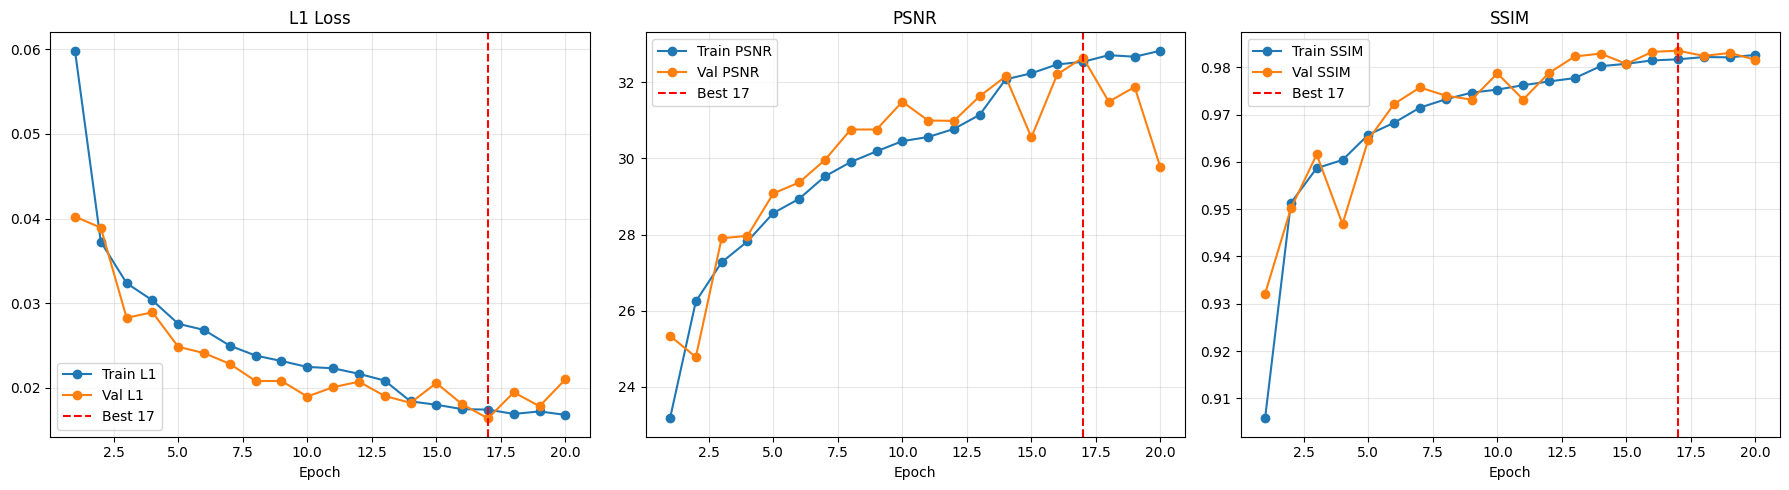

Best epoch: 17
Best val L1: 0.016411
Best val PSNR: 32.6509
Best val SSIM: 0.9835
Saved figure: /content/drive/MyDrive/deglare_experiments/Exp1_20260421_164308/training_curves_l1_psnr_ssim.png


In [81]:
if len(train_losses) == 0 and os.path.exists(METRICS_JSON):
    with open(METRICS_JSON, 'r') as f:
        hist = json.load(f)
    train_losses = hist['train_losses']
    val_losses = hist['val_losses']
    train_psnrs = hist['train_psnrs']
    val_psnrs = hist['val_psnrs']
    train_ssims = hist['train_ssims']
    val_ssims = hist['val_ssims']

epochs = np.arange(1, len(train_losses) + 1)
best_epoch_plot = int(np.argmin(val_losses)) + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, train_losses, marker='o', label='Train L1')
axes[0].plot(epochs, val_losses, marker='o', label='Val L1')
axes[0].axvline(best_epoch_plot, color='red', linestyle='--', label=f'Best {best_epoch_plot}')
axes[0].set_title('L1 Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, train_psnrs, marker='o', label='Train PSNR')
axes[1].plot(epochs, val_psnrs, marker='o', label='Val PSNR')
axes[1].axvline(best_epoch_plot, color='red', linestyle='--', label=f'Best {best_epoch_plot}')
axes[1].set_title('PSNR')
axes[1].set_xlabel('Epoch')
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(epochs, train_ssims, marker='o', label='Train SSIM')
axes[2].plot(epochs, val_ssims, marker='o', label='Val SSIM')
axes[2].axvline(best_epoch_plot, color='red', linestyle='--', label=f'Best {best_epoch_plot}')
axes[2].set_title('SSIM')
axes[2].set_xlabel('Epoch')
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
curve_path = os.path.join(EXP_DIR, 'training_curves_l1_psnr_ssim.png')
plt.savefig(curve_path, dpi=150)
plt.show()

print('Best epoch:', best_epoch_plot)
print(f"Best val L1: {val_losses[best_epoch_plot - 1]:.6f}")
print(f"Best val PSNR: {val_psnrs[best_epoch_plot - 1]:.4f}")
print(f"Best val SSIM: {val_ssims[best_epoch_plot - 1]:.4f}")
print('Saved figure:', curve_path)

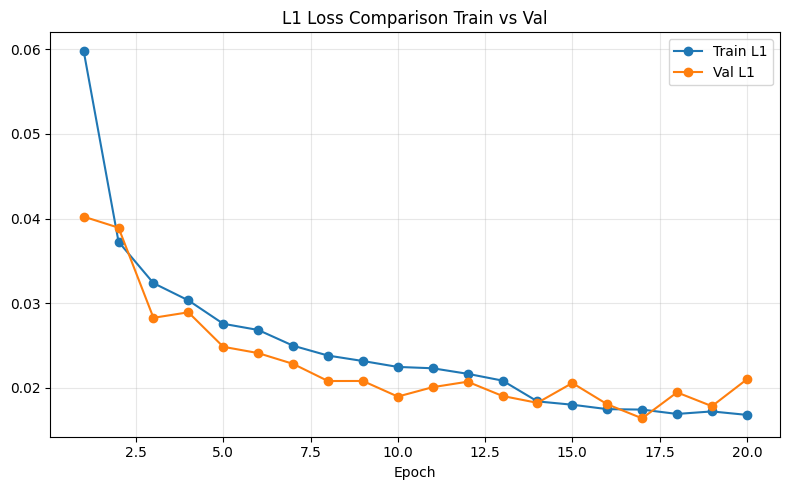

Best epoch: 17
Best val L1: 0.016411
Best val PSNR: 32.6509
Best val SSIM: 0.9835
Saved figure: /content/drive/MyDrive/deglare_experiments/Exp1_20260421_164308/training_curves_l1_only.png


In [85]:
if len(train_losses) == 0 and os.path.exists(METRICS_JSON):
    with open(METRICS_JSON, 'r') as f:
        hist = json.load(f)
    train_losses = hist['train_losses']
    val_losses = hist['val_losses']
    train_psnrs = hist['train_psnrs']
    val_psnrs = hist['val_psnrs']
    train_ssims = hist['train_ssims']
    val_ssims = hist['val_ssims']

epochs = np.arange(1, len(train_losses) + 1)
best_epoch_plot = int(np.argmin(val_losses)) + 1

fig, axes = plt.subplots(1, 1, figsize=(8, 5))

axes.plot(epochs, train_losses, marker='o', label='Train L1')
axes.plot(epochs, val_losses, marker='o', label='Val L1')
# axes.axvline(best_epoch_plot, color='red', linestyle='--', label=f'Best {best_epoch_plot}')
axes.set_title('L1 Loss Comparison Train vs Val')
axes.set_xlabel('Epoch')
axes.grid(alpha=0.3)
axes.legend()

# axes[1].plot(epochs, train_psnrs, marker='o', label='Train PSNR')
# axes[1].plot(epochs, val_psnrs, marker='o', label='Val PSNR')
# axes[1].axvline(best_epoch_plot, color='red', linestyle='--', label=f'Best {best_epoch_plot}')
# axes[1].set_title('PSNR')
# axes[1].set_xlabel('Epoch')
# axes[1].grid(alpha=0.3)
# axes[1].legend()

# axes[2].plot(epochs, train_ssims, marker='o', label='Train SSIM')
# axes[2].plot(epochs, val_ssims, marker='o', label='Val SSIM')
# axes[2].axvline(best_epoch_plot, color='red', linestyle='--', label=f'Best {best_epoch_plot}')
# axes[2].set_title('SSIM')
# axes[2].set_xlabel('Epoch')
# axes[2].grid(alpha=0.3)
# axes[2].legend()

plt.tight_layout()
curve_path = os.path.join(EXP_DIR, 'training_curves_l1_only.png')
plt.savefig(curve_path, dpi=150)
plt.show()

print('Best epoch:', best_epoch_plot)
print(f"Best val L1: {val_losses[best_epoch_plot - 1]:.6f}")
print(f"Best val PSNR: {val_psnrs[best_epoch_plot - 1]:.4f}")
print(f"Best val SSIM: {val_ssims[best_epoch_plot - 1]:.4f}")
print('Saved figure:', curve_path)

# SECTION 7 — FINAL VALIDATION EVALUATION

Reload best checkpoint and run full validation. Report final L1/PSNR/SSIM and pass/fail for target `L1 < 0.06`.

In [82]:
best_ckpt_path = BEST_MODEL_EXP_PATH if os.path.exists(BEST_MODEL_EXP_PATH) else BEST_CHECKPOINT_PATH
print('Loading best checkpoint:', best_ckpt_path)

best_ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
eval_model = DeglarUNet(**best_ckpt.get('model_config', TRAIN_MODEL_CONFIG)).to(DEVICE)
eval_model.load_state_dict(best_ckpt['model_state_dict'])
eval_model.eval()

val_l1_vals, val_psnr_vals, val_ssim_vals = [], [], []
with torch.no_grad():
    for glare, gt in tqdm(val_loader, desc='Final Validation', leave=False):
        glare = glare.to(DEVICE, non_blocking=True)
        gt = gt.to(DEVICE, non_blocking=True)
        pred = eval_model(glare)

        val_l1_vals.append(float(nn.functional.l1_loss(pred, gt).item()))
        p, s = compute_metrics(pred, gt)
        val_psnr_vals.append(p)
        val_ssim_vals.append(s)

final_l1 = float(np.mean(val_l1_vals))
final_psnr = float(np.mean(val_psnr_vals))
final_ssim = float(np.mean(val_ssim_vals))

print('\n========== FINAL VALIDATION SUMMARY =========')
print(f'Final L1   : {final_l1:.6f}')
print(f'Final PSNR : {final_psnr:.4f}')
print(f'Final SSIM : {final_ssim:.4f}')
print(f"Target check (L1 < 0.06): {'PASS' if final_l1 < 0.06 else 'FAIL'}")
print('============================================')

Loading best checkpoint: /content/drive/MyDrive/deglare_experiments/Exp1_20260421_164308/best_model.pth


Final Validation:   0%|          | 0/75 [00:00<?, ?it/s]


========== FINAL VALIDATION SUMMARY =========
Final L1   : 0.016411
Final PSNR : 32.6509
Final SSIM : 0.9835
Target check (L1 < 0.06): PASS


# SECTION 8 — INFERENCE DEMO

Pick 6 random validation samples, run inference, and display glare input with model output. Titles include per-image L1/PSNR/SSIM.

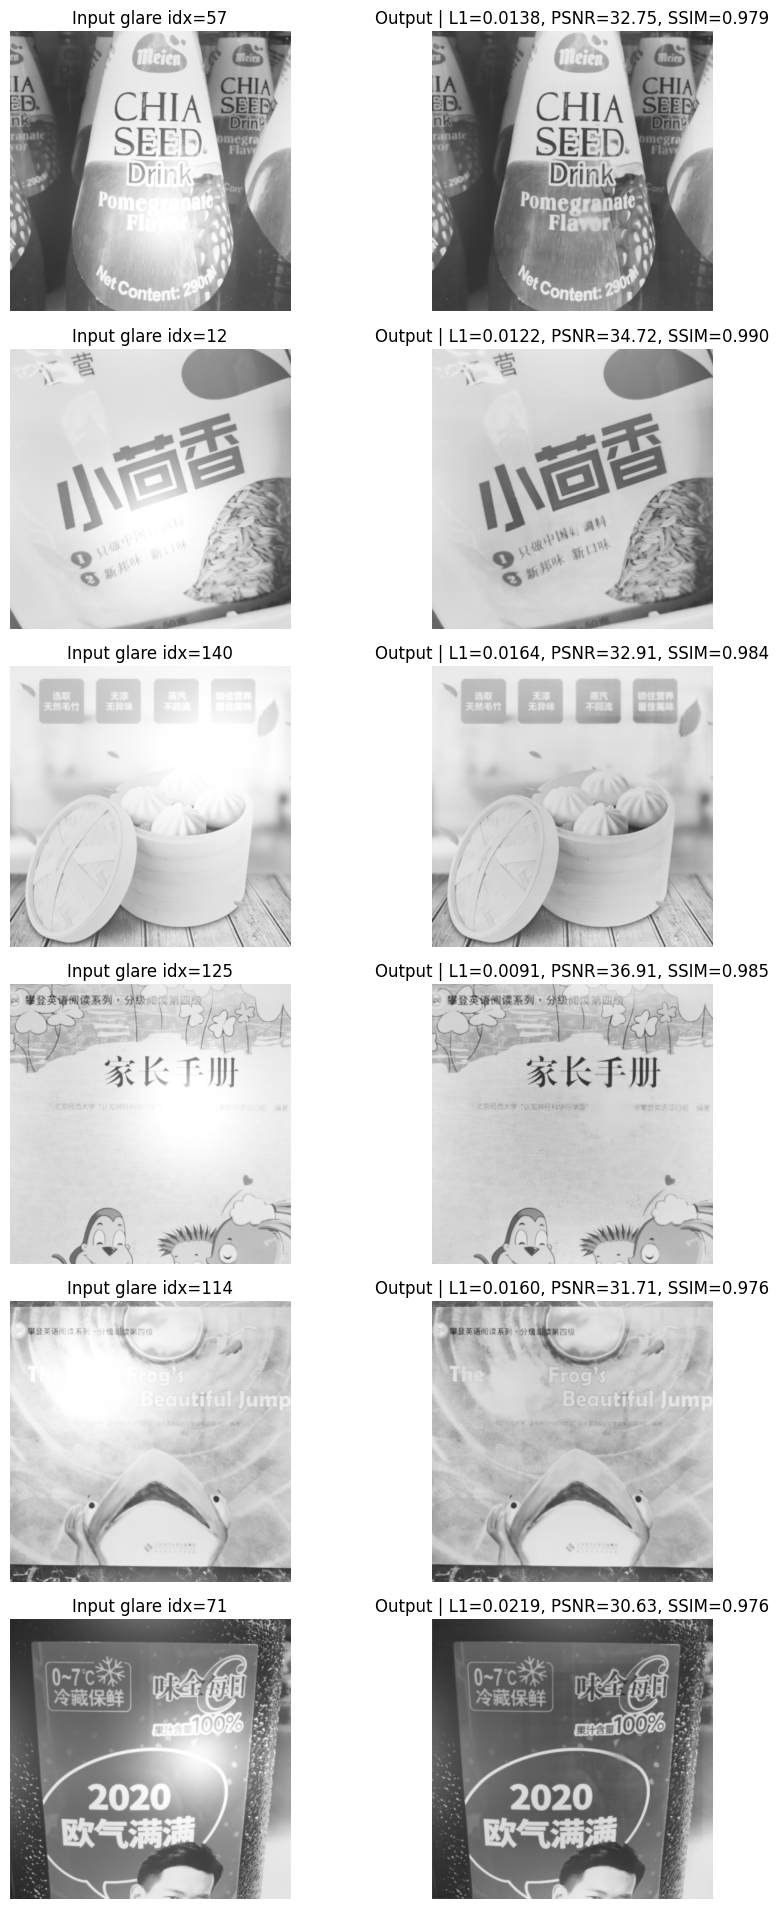

Saved inference figure: /content/drive/MyDrive/deglare_experiments/Exp1_20260421_164308/inference_demo.png


In [83]:
val_dataset = val_loader.dataset
n_demo = min(6, len(val_dataset))
indices = random.sample(range(len(val_dataset)), n_demo)

fig, axes = plt.subplots(n_demo, 2, figsize=(10, 3.2 * n_demo))
if n_demo == 1:
    axes = np.array([axes])

eval_model.eval()
with torch.no_grad():
    for row, idx in enumerate(indices):
        glare, gt = val_dataset[idx]
        x = glare.unsqueeze(0).to(DEVICE)
        y = gt.unsqueeze(0).to(DEVICE)

        pred = eval_model(x)
        l1_val = float(nn.functional.l1_loss(pred, y).item())
        p, s = compute_metrics(pred, y)

        glare_img = glare.squeeze(0).cpu().numpy()
        pred_img = pred.squeeze(0).squeeze(0).cpu().numpy()

        axes[row, 0].imshow(glare_img, cmap='gray', vmin=0.0, vmax=1.0)
        axes[row, 0].set_title(f'Input glare idx={idx}')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(pred_img, cmap='gray', vmin=0.0, vmax=1.0)
        axes[row, 1].set_title(f'Output | L1={l1_val:.4f}, PSNR={p:.2f}, SSIM={s:.3f}')
        axes[row, 1].axis('off')

plt.tight_layout()
infer_fig_path = os.path.join(EXP_DIR, 'inference_demo.png')
plt.savefig(infer_fig_path, dpi=150)
plt.show()
print('Saved inference figure:', infer_fig_path)